# Transmissivity Calculation Demonstration

This notebook demonstrates how transmissivity is computed at cell interfaces using harmonic means, based on the SoilGrid_2Dflow implementation from `soilprofile2D.py`. 

The key concept is computing transmissivity at cell faces (interfaces) as the harmonic mean of the two neighboring cells.

## 1. Import Libraries

In [7]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Define the rolling_window Helper Function

The `rolling_window` function creates a strided view of a 2D array with overlapping windows. This is used to extract neighboring cell pairs for transmissivity calculations at interfaces.

In [2]:
def rolling_window(a, window):
    """
    Returns a strided view of array a with a sliding window along the last axis.
    Used to compute harmonic-mean transmissivities at cell interfaces.

    Args:
        a      (array): 2D input array.
        window   (int): Window size (typically 2 for pairwise averaging).

    Returns:
        view (array): Shape (..., N - window + 1, window), no data copied.
    """
    shape = a.shape[:-1] + (a.shape[-1] - window + 1, window)
    strides = a.strides + (a.strides[-1],)
    return np.lib.stride_tricks.as_strided(a, shape=shape, strides=strides)

# Simple example: extract adjacent pairs from a row
test_row = np.array([[1, 2, 3, 4, 5]])
w = rolling_window(test_row, 2)
print("Test row:", test_row)
print("Rolling window output shape:", w.shape)
print("Adjacent pairs (window=2):")
print(w)
print('')
test_grid = np.array([[[1, 2, 3], 
                       [6, 7, 8], 
                       [11, 12, 13]]])
w = rolling_window(test_grid, 2)
print("Test grid:", test_grid)
print("Rolling window output shape:", w.shape)
print("Adjacent pairs (window=2):")
print(w)

Test row: [[1 2 3 4 5]]
Rolling window output shape: (1, 4, 2)
Adjacent pairs (window=2):
[[[1 2]
  [2 3]
  [3 4]
  [4 5]]]

Test grid: [[[ 1  2  3]
  [ 6  7  8]
  [11 12 13]]]
Rolling window output shape: (1, 3, 2, 2)
Adjacent pairs (window=2):
[[[[ 1  2]
   [ 2  3]]

  [[ 6  7]
   [ 7  8]]

  [[11 12]
   [12 13]]]]


## 3. Create a Dummy Transmissivity Grid (Tr0)

We create a small 5×5 grid of transmissivity values, including some zeros to test the safe-denominator logic. We also initialize the four directional arrays (TrW0, TrE0, TrN0, TrS0) to zeros.

In [3]:
# Create a small 5x5 transmissivity grid with mixed values and some zeros
Tr0 = np.array([
    [2.0, 1.5, 0.0, 1.0, 0.5],
    [1.0, 3.0, 2.5, 1.5, 0.0],
    [0.0, 2.0, 2.5, 1.0, 1.5],
    [1.5, 1.0, 1.5, 2.0, 1.0],
    [0.5, 0.0, 1.0, 1.5, 2.5]
], dtype=np.float64)

rows, cols = Tr0.shape
print(f"Grid shape: {rows} rows × {cols} columns")
print(f"\nOriginal Tr0 grid:\n{Tr0}")

# Initialize directional transmissivity arrays
TrW0 = np.zeros((rows, cols))
TrE0 = np.zeros((rows, cols))
TrN0 = np.zeros((rows, cols))
TrS0 = np.zeros((rows, cols))

print(f"\nInitialized directional arrays (all zeros): shape {TrW0.shape}")

Grid shape: 5 rows × 5 columns

Original Tr0 grid:
[[2.  1.5 0.  1.  0.5]
 [1.  3.  2.5 1.5 0. ]
 [0.  2.  2.5 1.  1.5]
 [1.5 1.  1.5 2.  1. ]
 [0.5 0.  1.  1.5 2.5]]

Initialized directional arrays (all zeros): shape (5, 5)


## 4. Compute Harmonic Mean at Cell Interfaces (EW and NS)

The harmonic mean is computed as: $\text{H.M.} = \frac{2ab}{a+b}$ where $a$ and $b$ are neighboring cells.

To avoid division by zero, we use a **safe denominator** approach:
- If $a + b > 0$: compute harmonic mean
- Otherwise: set to 0

In [4]:
print("="*70)
print("EAST-WEST (EW) DIRECTION - Harmonic mean along columns")
print("="*70)

# Get rolling window pairs along columns (East-West direction)
w_ew = rolling_window(Tr0, 2)
print(f"\nRolling window shape: {w_ew.shape}")
print(f"Meaning: {w_ew.shape[0]} rows, {w_ew.shape[1]} interface positions, {w_ew.shape[2]} neighbors per pair\n")

# Extract the two neighbors: left (a) and right (b)
a_ew = w_ew[..., 0]  # First neighbor (left)
b_ew = w_ew[..., 1]  # Second neighbor (right)

# Safe denominator: use 1.0 when both neighbors are 0
d_ew = np.where(a_ew + b_ew > 0, a_ew + b_ew, 1.0)

# Harmonic mean with safe denominator
TrTmpEW = np.where(a_ew + b_ew > 0, 2*a_ew*b_ew / d_ew, 0.0)

print("Example calculation at row 0:")
for i in range(w_ew.shape[1]):
    a, b = a_ew[0, i], b_ew[0, i]
    hm = TrTmpEW[0, i]
    print(f"  Interface {i}: Tr_left={a:.1f}, Tr_right={b:.1f} → H.M.={hm:.3f}")

print(f"\nTrTmpEW (harmonic mean at EW interfaces):\n{TrTmpEW}")

print("\n" + "="*70)
print("NORTH-SOUTH (NS) DIRECTION - Harmonic mean along rows")
print("="*70)

# Transpose Tr0 for N-S direction
Tr0_T = np.transpose(Tr0)
w_ns = rolling_window(Tr0_T, 2)

a_ns = w_ns[..., 0]
b_ns = w_ns[..., 1]
d_ns = np.where(a_ns + b_ns > 0, a_ns + b_ns, 1.0)
TrTmpNS_T = np.where(a_ns + b_ns > 0, 2*a_ns*b_ns / d_ns, 0.0)

# Transpose back to original orientation
TrTmpNS = np.transpose(TrTmpNS_T)

print(f"\nTrTmpNS (harmonic mean at NS interfaces, after transpose):\n{TrTmpNS}")

EAST-WEST (EW) DIRECTION - Harmonic mean along columns

Rolling window shape: (5, 4, 2)
Meaning: 5 rows, 4 interface positions, 2 neighbors per pair

Example calculation at row 0:
  Interface 0: Tr_left=2.0, Tr_right=1.5 → H.M.=1.714
  Interface 1: Tr_left=1.5, Tr_right=0.0 → H.M.=0.000
  Interface 2: Tr_left=0.0, Tr_right=1.0 → H.M.=0.000
  Interface 3: Tr_left=1.0, Tr_right=0.5 → H.M.=0.667

TrTmpEW (harmonic mean at EW interfaces):
[[1.71428571 0.         0.         0.66666667]
 [1.5        2.72727273 1.875      0.        ]
 [0.         2.22222222 1.42857143 1.2       ]
 [1.2        1.2        1.71428571 1.33333333]
 [0.         0.         1.2        1.875     ]]

NORTH-SOUTH (NS) DIRECTION - Harmonic mean along rows

TrTmpNS (harmonic mean at NS interfaces, after transpose):
[[1.33333333 2.         0.         1.2        0.        ]
 [0.         2.4        2.5        1.2        0.        ]
 [0.         1.33333333 1.875      1.33333333 1.2       ]
 [0.75       0.         1.2        1

## 5. Assign Interface Transmissivities to Directional Arrays

The harmonic means are now assigned to the four directional arrays using specific slicing patterns:
- **TrW0** (West):  receives EW values in columns 1:  (shifted right)
- **TrE0** (East):  receives EW values in columns :-1 (shifted left)
- **TrN0** (North): receives NS values in rows 1:   (shifted down)
- **TrS0** (South): receives NS values in rows :-1  (shifted up)

In [5]:
# Assign EW interface transmissivities
# TrW0[i, j] = transmissivity on the west face of cell (i,j)
# TrE0[i, j] = transmissivity on the east face of cell (i,j)
TrW0[:, 1:] = TrTmpEW
TrE0[:, :-1] = TrTmpEW

# Assign NS interface transmissivities
# TrN0[i, j] = transmissivity on the north face of cell (i,j)
# TrS0[i, j] = transmissivity on the south face of cell (i,j)
TrN0[1:, :] = TrTmpNS
TrS0[:-1, :] = TrTmpNS

print("After assignment:")
print(f"\nTrW0 (West interface transmissivities):\n{TrW0}")
print(f"\nTrE0 (East interface transmissivities):\n{TrE0}")
print(f"\nTrN0 (North interface transmissivities):\n{TrN0}")
print(f"\nTrS0 (South interface transmissivities):\n{TrS0}")

# Verify: check a specific cell and its interface transmissivities
print("\n" + "="*70)
print("Verification: Cell (2, 2) and its interface transmissivities")
print("="*70)
i, j = 2, 2
print(f"Cell ({i},{j}) center Tr0: {Tr0[i, j]:.2f}")
print(f"  West face (TrW0):  {TrW0[i, j]:.2f}")
print(f"  East face (TrE0):  {TrE0[i, j]:.2f}")
print(f"  North face (TrN0): {TrN0[i, j]:.2f}")
print(f"  South face (TrS0): {TrS0[i, j]:.2f}")

After assignment:

TrW0 (West interface transmissivities):
[[0.         1.71428571 0.         0.         0.66666667]
 [0.         1.5        2.72727273 1.875      0.        ]
 [0.         0.         2.22222222 1.42857143 1.2       ]
 [0.         1.2        1.2        1.71428571 1.33333333]
 [0.         0.         0.         1.2        1.875     ]]

TrE0 (East interface transmissivities):
[[1.71428571 0.         0.         0.66666667 0.        ]
 [1.5        2.72727273 1.875      0.         0.        ]
 [0.         2.22222222 1.42857143 1.2        0.        ]
 [1.2        1.2        1.71428571 1.33333333 0.        ]
 [0.         0.         1.2        1.875      0.        ]]

TrN0 (North interface transmissivities):
[[0.         0.         0.         0.         0.        ]
 [1.33333333 2.         0.         1.2        0.        ]
 [0.         2.4        2.5        1.2        0.        ]
 [0.         1.33333333 1.875      1.33333333 1.2       ]
 [0.75       0.         1.2        1.7142857

## 6. Visualize Results

Heatmaps of the center transmissivities (Tr0) and the four directional interface transmissivities. Notice where zeros appear when one or both neighbors are zero (safe-denominator logic at work).

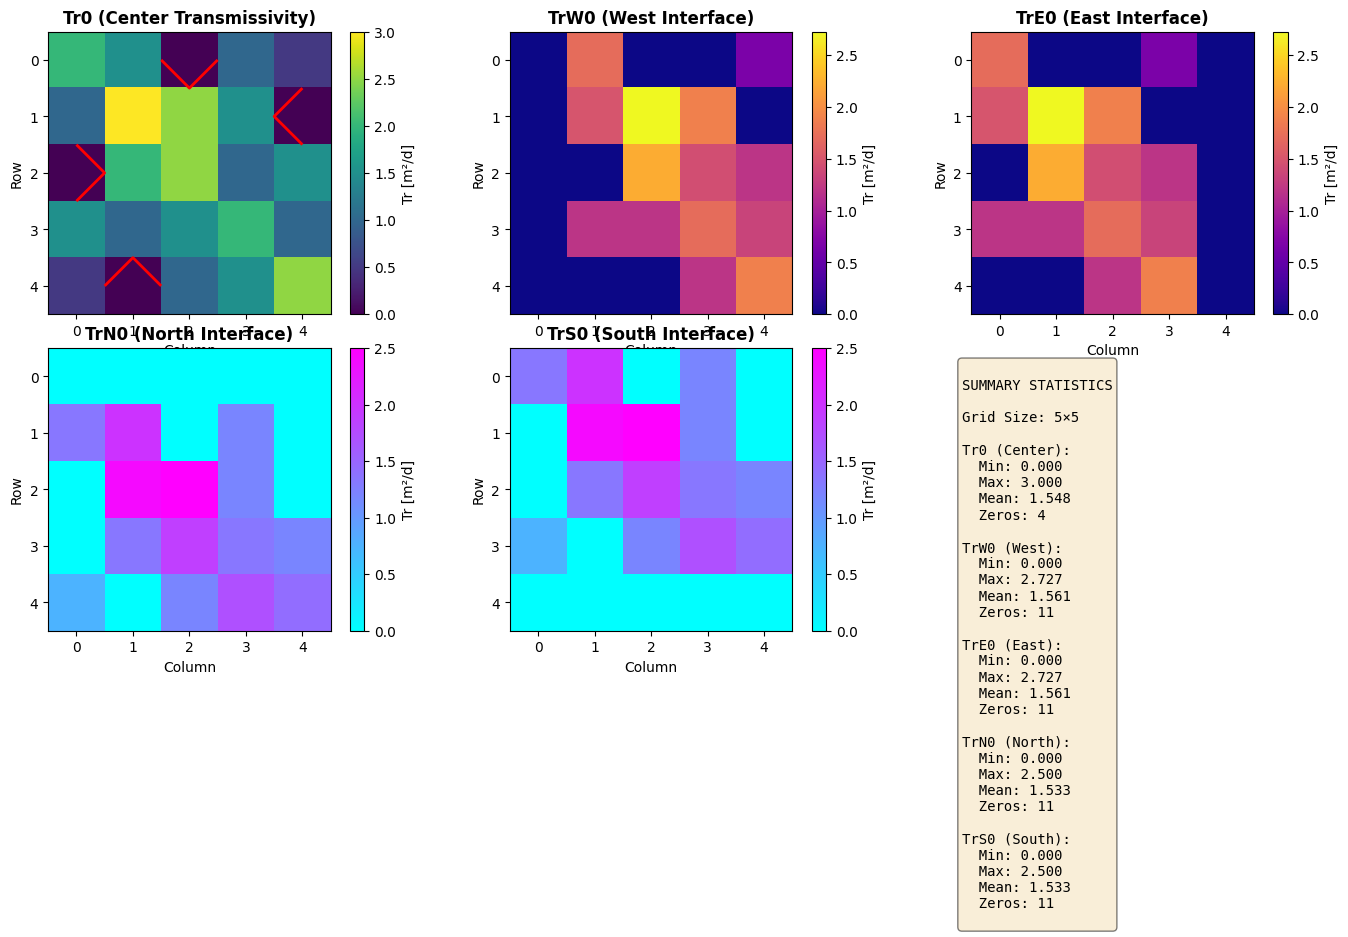


Visualization complete! Figure saved as 'transmissivity_interfaces.png'


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

# Plot Tr0 (center)
im0 = axes[0, 0].imshow(Tr0, cmap='viridis', interpolation='nearest')
axes[0, 0].set_title('Tr0 (Center Transmissivity)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Column')
axes[0, 0].set_ylabel('Row')
plt.colorbar(im0, ax=axes[0, 0], label='Tr [m²/d]')

# Overlay zero locations
zero_mask = Tr0 == 0
axes[0, 0].contour(zero_mask, levels=[0.5], colors='red', linewidths=2)

# Plot TrW0 (West interface)
im_w = axes[0, 1].imshow(TrW0, cmap='plasma', interpolation='nearest')
axes[0, 1].set_title('TrW0 (West Interface)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Column')
axes[0, 1].set_ylabel('Row')
plt.colorbar(im_w, ax=axes[0, 1], label='Tr [m²/d]')

# Plot TrE0 (East interface)
im_e = axes[0, 2].imshow(TrE0, cmap='plasma', interpolation='nearest')
axes[0, 2].set_title('TrE0 (East Interface)', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Column')
axes[0, 2].set_ylabel('Row')
plt.colorbar(im_e, ax=axes[0, 2], label='Tr [m²/d]')

# Plot TrN0 (North interface)
im_n = axes[1, 0].imshow(TrN0, cmap='cool', interpolation='nearest')
axes[1, 0].set_title('TrN0 (North Interface)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Column')
axes[1, 0].set_ylabel('Row')
plt.colorbar(im_n, ax=axes[1, 0], label='Tr [m²/d]')

# Plot TrS0 (South interface)
im_s = axes[1, 1].imshow(TrS0, cmap='cool', interpolation='nearest')
axes[1, 1].set_title('TrS0 (South Interface)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Column')
axes[1, 1].set_ylabel('Row')
plt.colorbar(im_s, ax=axes[1, 1], label='Tr [m²/d]')

# Summary statistics
ax_text = axes[1, 2]
ax_text.axis('off')
summary_text = f"""
SUMMARY STATISTICS

Grid Size: {rows}×{cols}

Tr0 (Center):
  Min: {Tr0.min():.3f}
  Max: {Tr0.max():.3f}
  Mean: {Tr0[Tr0>0].mean():.3f}
  Zeros: {(Tr0==0).sum()}

TrW0 (West):
  Min: {TrW0.min():.3f}
  Max: {TrW0.max():.3f}
  Mean: {TrW0[TrW0>0].mean():.3f}
  Zeros: {(TrW0==0).sum()}

TrE0 (East):
  Min: {TrE0.min():.3f}
  Max: {TrE0.max():.3f}
  Mean: {TrE0[TrE0>0].mean():.3f}
  Zeros: {(TrE0==0).sum()}

TrN0 (North):
  Min: {TrN0.min():.3f}
  Max: {TrN0.max():.3f}
  Mean: {TrN0[TrN0>0].mean():.3f}
  Zeros: {(TrN0==0).sum()}

TrS0 (South):
  Min: {TrS0.min():.3f}
  Max: {TrS0.max():.3f}
  Mean: {TrS0[TrS0>0].mean():.3f}
  Zeros: {(TrS0==0).sum()}
"""
ax_text.text(0.05, 0.95, summary_text, transform=ax_text.transAxes, 
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## Key Insights

### Harmonic Mean Properties
- The **harmonic mean** is ideal for transmissivity because it gives more weight to lower values
- Formula: $\text{H.M.} = \frac{2ab}{a+b}$ preserves hydraulic conductivity better than arithmetic mean
- Example: If a cell has Tr=2.0 and neighbor has Tr=0.5, H.M. = 2(2.0)(0.5)/(2.0+0.5) ≈ 0.8 (closer to limiting value)

### Safe Denominator Pattern
- The condition `where(a+b > 0, ..., 0.0)` ensures:
  - **Valid pair**: both neighbors have positive Tr → compute harmonic mean
  - **One zero**: only one neighbor is 0 → harmonic mean still computed but smaller
  - **Both zero**: both neighbors are 0 → set interface Tr to 0 (no flow possible)

### Directional Array Slicing
The slicing patterns `[:,1:]`, `[:,:-1]`, `[1:,:]`, `[:-1,:]` ensure that:
- Interface transmissivities are properly aligned with each cell's faces
- Boundary cells (first/last row/column) have zero interface Tr on one side (edge condition)

### Practical Application
This method ensures that:
1. Flow is calculated correctly across cell boundaries using interface transmissivities
2. Impermeable zones (Tr=0) are properly handled without computational errors
3. The groundwater flow equations remain stable during finite-difference solving